# 🧩 Reto 4 – Integración de resultados
**Objetivo:** combinar resultados parciales en un diagnóstico integral por sitio.

### Pasos
1. Carga `resultado_temperatura.csv`, `resultado_ph.csv`, `resultado_oxigeno.csv`.
2. Únelos por `sitio` usando `merge`.
3. Crea `diagnostico_final` con reglas (parcial/total/normal).
4. Exporta `diagnostico_final.csv`.
5. Cuenta categorías con `value_counts()`.

> **Reto adicional:** gráfico de barras de distribución.

In [ ]:
import pandas as pd
#import matplotlib.pyplot as plt
df = pd.read_csv("../data/muestras_calidad_agua.csv")
# Mostrar las primeras filas del DataFrame para verificar que se ha cargado correctamente
print(df.head())    


                          sitio   pH  oxigeno  temperatura
0                Río Subachoque  7.2      7.8         18.5
1   Quebrada Honda (Facatativá)  6.3      6.2         19.4
2          Río Botello (Madrid)  6.8      5.9         22.7
3  Afluente San José (El Rosal)  7.9      8.3         20.1
4                   Río Villeta  8.7      6.1         28.3


In [2]:
# Generar los DataFrames de resultados (simulando los CSVs generados)
# Para temperatura
df_temp = df[['sitio', 'temperatura']].copy()
def riesgo_temperatura(temp):
    if temp < 20:
        return "Baja"
    elif temp <= 26:
        return "Media"
    else:
        return "Alta"
df_temp['riesgo_termico'] = df_temp['temperatura'].apply(riesgo_temperatura)

# Para pH
df_ph = df[['sitio', 'pH']].copy()
def clasificar_ph(ph):
    if ph < 6.5:
        return "Ácida"
    elif ph <= 8.5:
        return "Normal"
    else:
        return "Alcalina"
df_ph['estado'] = df_ph['pH'].apply(clasificar_ph)
def alerta_ph(ph):
    if ph < 5:
        return "⚠️ Riesgo químico alto"
    elif ph <= 8.5:
        return " Agua segura"
    else:
        return "⚠️ Riesgo alcalino"
df_ph['alerta'] = df_ph['pH'].apply(alerta_ph)

# Para oxígeno
df_oxigeno = df[['sitio', 'oxigeno']].copy()
def clasificar_oxigeno(ox):
    if ox < 5:
        return "Bajo"
    elif ox <= 8:
        return "Medio"
    else:
        return "Alto"
df_oxigeno['nivel_oxigeno'] = df_oxigeno['oxigeno'].apply(clasificar_oxigeno)
df_oxigeno['riesgo_biologico'] = df_oxigeno['oxigeno'] < 5

print("DataFrames generados correctamente")

DataFrames generados correctamente


In [3]:
# Unir los DataFrames por 'sitio' usando merge
df_merged = df_temp.merge(df_ph, on='sitio').merge(df_oxigeno, on='sitio')
print(df_merged.head())

                          sitio  temperatura riesgo_termico   pH    estado  \
0                Río Subachoque         18.5           Baja  7.2    Normal   
1   Quebrada Honda (Facatativá)         19.4           Baja  6.3     Ácida   
2          Río Botello (Madrid)         22.7          Media  6.8    Normal   
3  Afluente San José (El Rosal)         20.1          Media  7.9    Normal   
4                   Río Villeta         28.3           Alta  8.7  Alcalina   

               alerta  oxigeno nivel_oxigeno  riesgo_biologico  
0         Agua segura      7.8         Medio             False  
1         Agua segura      6.2         Medio             False  
2         Agua segura      5.9         Medio             False  
3         Agua segura      8.3          Alto             False  
4  ⚠️ Riesgo alcalino      6.1         Medio             False  


In [4]:
# Crear diagnostico_final con reglas
def determinar_diagnostico(row):
    riesgos = 0
    if row['riesgo_termico'] != 'Baja':
        riesgos += 1
    if row['estado'] != 'Normal':
        riesgos += 1
    if row['riesgo_biologico'] == True:
        riesgos += 1
    if riesgos == 0:
        return 'normal'
    elif riesgos == 1:
        return 'parcial'
    else:
        return 'total'

df_merged['diagnostico_final'] = df_merged.apply(determinar_diagnostico, axis=1)
print(df_merged[['sitio', 'diagnostico_final']])

                           sitio diagnostico_final
0                 Río Subachoque            normal
1    Quebrada Honda (Facatativá)           parcial
2           Río Botello (Madrid)           parcial
3   Afluente San José (El Rosal)           parcial
4                    Río Villeta             total
5  Quebrada Cune (San Francisco)             total
6            Río Tobia (Nocaima)           parcial
7       Quebrada Negra (La Vega)           parcial
8          Río Bahamón (Sasaima)           parcial
9        Río Guayuriba (La Mesa)             total


In [5]:
# Exportar diagnostico_final.csv
df_merged.to_csv("../data/diagnostico_final.csv", index=False)
print("Archivo diagnostico_final.csv exportado correctamente")

Archivo diagnostico_final.csv exportado correctamente


In [6]:
# Contar categorías con value_counts()
conteo_categorias = df_merged['diagnostico_final'].value_counts()
print(conteo_categorias)

diagnostico_final
parcial    6
total      3
normal     1
Name: count, dtype: int64


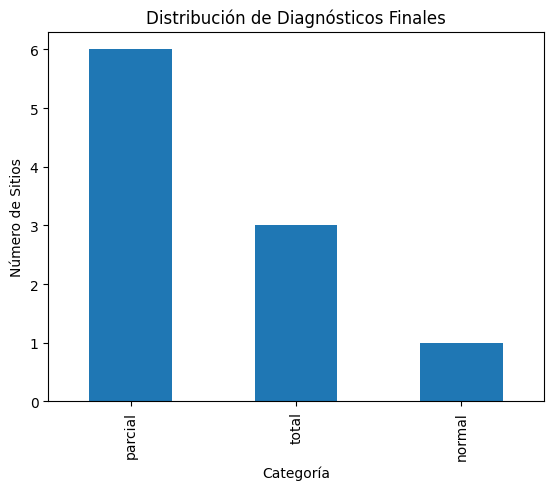

In [7]:
# Reto adicional: gráfico de barras de distribución
import matplotlib.pyplot as plt

conteo_categorias.plot(kind='bar')
plt.title('Distribución de Diagnósticos Finales')
plt.xlabel('Categoría')
plt.ylabel('Número de Sitios')
plt.show()